# 03_price_prediction.ipynb


**Mục tiêu:**


# Thư viện

In [33]:
import warnings
warnings.simplefilter('ignore')

import json
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError as error:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = error

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError as error:
    CatBoostRegressor = None
    CATBOOST_AVAILABLE = False
    CATBOOST_IMPORT_ERROR = error


def find_project_root(start_path=None):
    """Find the repository root without depending on the notebook working directory."""
    current_path = Path(start_path or Path.cwd()).resolve()
    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "README.md").exists()
        ) or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Project root could not be found from the current directory.")


PROJECT_ROOT = find_project_root()
TARGET = "log_price"
TEST_SIZE = 0.2
N_SPLITS = 5
RANDOM_STATE = 42
RUN_STARTED_AT = datetime.now().isoformat(timespec="seconds")

PRICE_MODELING_OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs" / "price_modeling"
OUTPUT_DIRS = {
    "csv": PRICE_MODELING_OUTPUT_DIR / "csv",
    "charts": PRICE_MODELING_OUTPUT_DIR / "charts",
    "models": PRICE_MODELING_OUTPUT_DIR / "models",
    "metadata": PRICE_MODELING_OUTPUT_DIR / "metadata",
}

for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)


def format_output_path(output_path):
    return output_path.relative_to(PROJECT_ROOT).as_posix()


def save_dataframe(dataframe, filename):
    output_path = OUTPUT_DIRS["csv"] / filename
    dataframe.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def save_figure(filename, figure=None):
    output_path = OUTPUT_DIRS["charts"] / filename
    if figure is not None:
        plt.figure(figure.number)
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Series):
        return value.to_dict()
    if isinstance(value, pd.DataFrame):
        return value.to_dict(orient="records")
    if isinstance(value, Path):
        return value.as_posix()
    return str(value)


def save_json(data, filename):
    output_path = OUTPUT_DIRS["metadata"] / filename
    with output_path.open("w", encoding="utf-8") as file:
        json.dump(
            data,
            file,
            indent=4,
            ensure_ascii=False,
            default=json_default,
        )
    print(f"Saved: {format_output_path(output_path)}")
    return output_path


print(f"Project root: {PROJECT_ROOT}")
print(f"Output root: {format_output_path(PRICE_MODELING_OUTPUT_DIR)}")


Project root: D:\Projects\Y2026_Sources\airbnb-analytics-platform
Output root: ml/outputs/price_modeling


# Dữ liệu

In [2]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.motherduck import connect_motherduck
from utils.sql import query_dataframe

connection = connect_motherduck(read_only=True)


In [3]:
df_model = query_dataframe(
    connection,
    """
    select *
    from airbnb_analytics.gold.listing_features
    """
)

print("Kích thước dữ liệu:", df_model.shape)
df_model.head()

Kích thước dữ liệu: (23273, 32)


,listing_id,host_id,neighbourhood,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,has_reviews,amenities_count,log_price
0,441869,699499,Vadhana,Private room in rental unit,Private room,4,1.0,1.0,2.0,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,15,7.283448
1,788043,4070562,Khlong San,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,30,...,4.99,4.97,4.96,4.97,4.99,4.78,4.89,1,35,6.580639
2,820395,822284,Bang Sue,Entire guesthouse,Entire home/apt,2,1.0,1.0,1.0,7,...,4.80,4.86,4.73,4.87,4.93,4.00,4.73,1,19,6.857514
3,1060320,5171292,Khlong San,Shared room in rental unit,Shared room,12,6.5,1.0,12.0,1,...,4.50,4.67,4.58,4.83,4.92,4.00,4.33,1,16,5.549076
4,1412787,7616231,Khlong San,Entire rental unit,Entire home/apt,4,1.0,1.0,2.0,3,...,4.69,4.77,4.68,4.55,4.70,4.76,4.70,1,33,7.483807


## Hàm xử lý cố định

**Mục tiêu:**
- Do `property_type` có 74 giá trị gây khó khăn cho quá trình Encoding, vì vậy, thực hiện gom nhóm property theo loại tài sản nhằm giảm số lượng cột khi thực hiện One-Hot Encoding.
- Điền khuyến 0 cho `review_per_month`

In [4]:
def group_property_type(value):
    """Gom property_type thành property_base_group."""

    if pd.isna(value):
        return "Unknown"

    text = str(value).lower().strip()

    if any(k in text for k in ["serviced apartment", "aparthotel"]):
        return "Serviced Apartment / Aparthotel"

    if "hostel" in text:
        return "Hostel"

    if any(k in text for k in [
        "guesthouse", "guest house", "bed and breakfast"
    ]):
        return "Guesthouse / B&B"

    if any(k in text for k in [
        "hotel", "resort", "ryokan", "kezhan"
    ]):
        return "Hotel / Resort"

    if "villa" in text:
        return "Villa"

    if "loft" in text:
        return "Loft"

    if any(k in text for k in [
        "rental unit", "condo", "apartment"
    ]):
        return "Apartment / Condo"

    if any(k in text for k in [
        "treehouse", "tiny home", "earthen home",
        "earth home", "dome", "tower", "lighthouse",
        "castle", "shipping container", "container",
        "hut", "tent"
    ]):
        return "Unique Stay"

    if any(k in text for k in [
        "cabin", "nature lodge", "farm stay", "barn",
        "houseboat", "boat", "island", "camper/rv"
    ]):
        return "Special Stay"

    if any(k in text for k in [
        "townhouse", "guest suite", "vacation home",
        "casa particular", "bungalow", "cottage",
        "chalet", "house", "home"
    ]):
        return "House / Home"

    return "Other"


def prepare_features(df):
    """
    Xử lý cố định trước khi chia train/test:
    - Gom property_type thành property_base_group
    - Gán reviews_per_month = 0 cho listing không có review
    """

    data = df.copy()

    # Gom loại tài sản
    data["property_base_group"] = (
        data["property_type"]
        .apply(group_property_type)
    )

    # Bỏ property_type gốc
    data = data.drop(
        columns=["property_type"],
        errors="ignore"
    )

    # Listing không có review thì reviews_per_month = 0
    if {"has_reviews", "reviews_per_month"}.issubset(data.columns):
        data.loc[
            data["has_reviews"] == 0,
            "reviews_per_month"
        ] = 0

    return data

In [5]:
# Áp dụng
df_model = prepare_features(df_model)

display(
    df_model["property_base_group"]
    .value_counts()
    .to_frame("listing_count")
)

,listing_count
property_base_group,
Apartment / Condo,16731
House / Home,3066
Hotel / Resort,1565
Serviced Apartment / Aparthotel,640
Guesthouse / B&B,455
Hostel,361
Loft,180
Villa,97
Unique Stay,90


## Xác định biến đầu vào và biến mục tiêu

In [6]:
# Tách biến mục tiêu
y = df_model[TARGET].copy()

# Tách biến đầu vào
X = df_model.drop(
    columns=[TARGET] + ['listing_id', 'host_id']
).copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)


Kích thước X: (23273, 29)
Kích thước y: (23273,)


In [7]:
y.describe()

count    23273.000000
mean         7.327586
std          0.758660
min          1.609438
25%          6.828712
50%          7.229839
75%          7.699842
max         13.815512
Name: log_price, dtype: float64

In [8]:
feature_types = pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing_count": X.isna().sum().values,
    "missing_rate": (
        X.isna().mean().mul(100).round(2).values
    ),
    "unique_count": X.nunique(dropna=True).values
})

save_dataframe(feature_types, "01_feature_quality_summary.csv")
feature_types


,feature,dtype,missing_count,missing_rate,unique_count
0,neighbourhood,str,0,0.00,50
1,room_type,str,0,0.00,4
2,accommodates,int32,0,0.00,16
3,bathrooms,float64,60,0.26,31
4,bedrooms,float64,88,0.38,20
5,beds,float64,53,0.23,32
6,minimum_nights,int32,0,0.00,83
7,maximum_nights,int32,0,0.00,136
8,instant_bookable,bool,0,0.00,2
9,host_response_time,str,7,0.03,5


In [9]:
# Phân nhóm các biến
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

boolean_features = X.select_dtypes(
    include=["bool", "boolean"]
).columns.tolist()

print("Biến số:", len(numeric_features))
print("Biến phân loại:", len(categorical_features))
print("Biến boolean:", len(boolean_features))

Biến số: 23
Biến phân loại: 4
Biến boolean: 2


# Chia tập dữ liệu

In [10]:
id_columns = [
    col for col in ["listing_id", "host_id"]
    if col in df_model.columns
]

# Lưu metadata riêng
metadata = df_model[id_columns].copy()

# Biến mục tiêu
y = df_model[TARGET].copy()

# Biến đầu vào, không chứa ID và target
X = df_model.drop(
    columns=[TARGET] + id_columns
).copy()

# Chia dữ liệu
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    metadata,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X train:", X_train.shape)
print("X test:", X_test.shape)
print("y train:", y_train.shape)
print("y test:", y_test.shape)


X train: (18618, 29)
X test: (4655, 29)
y train: (18618,)
y test: (4655,)


In [11]:
# Check log_price distribution in train and test sets
target_split_summary = pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe()
})

save_dataframe(
    target_split_summary.reset_index().rename(columns={"index": "statistic"}),
    "02_target_split_summary.csv",
)
target_split_summary


,train,test
count,18618.000000,4655.000000
mean,7.323807,7.342697
std,0.760417,0.751482
min,1.609438,5.517453
25%,6.827629,6.843750
50%,7.228388,7.241366
75%,7.696213,7.725771
max,13.815512,13.815512


**Nhận xét:** Tập train và test có phân phối log_price ***tương đối tương đồng*** về trung bình, trung vị, độ lệch chuẩn và các phân vị. Điều này cho thấy phép chia dữ liệu ngẫu nhiên giữ được cấu trúc phân phối chung của biến mục tiêu. Tuy nhiên, ***tập train chứa một số giá trị thấp*** không xuất hiện trong tập test, vì vậy cần tiếp tục theo dõi sai số ở các phân khúc giá thấp trong bước đánh giá mô hình.

# Pipeline tiền xử lý dữ liệu

**Tổng hợp pipeline tiền xử lý dữ liệu:**

| Nhóm biến | Biến | Cách xử lý |
|---|---|---|
| Biến mục tiêu | `price` | Loại các dòng có `price` thiếu, bằng 0 hoặc âm |
| Biến mục tiêu | `price` | Tạo `log_price = log1p(price)` và sử dụng `log_price` làm target |
| Định danh | `listing_id`, `host_id` | Loại khỏi tập feature, chỉ giữ lại để truy vết kết quả |
| Quy mô chỗ ở | `accommodates` | Giữ nguyên và kiểm tra các giá trị bất hợp lý |
| Quy mô chỗ ở | `bedrooms`, `bathrooms`, `beds` | Điền giá trị thiếu bằng median |
| Loại phòng | `room_type` | One-Hot Encoding |
| Loại tài sản | `property_type` | Gom từ 74 nhóm xuống khoảng 10–14 nhóm tài sản |
| Loại tài sản | `property_group` | One-Hot Encoding sau khi gom nhóm |
| Vị trí | `neighbourhood` | Giữ nguyên và One-Hot Encoding |
| Host | `host_response_rate`, `host_acceptance_rate` | Chuyển chuỗi phần trăm sang số trong khoảng `0–1` |
| Host | `host_response_rate`, `host_acceptance_rate` | Điền giá trị thiếu bằng median |
| Host | `host_response_time` | Điền giá trị thiếu bằng `"Unknown"` |
| Host | `host_response_time` | One-Hot Encoding |
| Host | `host_is_superhost` | Giá trị thiếu điền `0` |
| Host | `host_listings_count`, `host_total_listings_count` | Điền giá trị thiếu bằng median |
| Review | `number_of_reviews` | Giữ nguyên giá trị `0` |
| Review | `number_of_reviews_ltm` | Giữ nguyên giá trị `0` |
| Review | `reviews_per_month` | Điền `0` nếu listing chưa có review |
| Review | Các biến `review_scores_*` | Điền median và tạo cờ thiếu; có thể giữ NaN tự nhiên với CatBoost, XGBoost hoặc LightGBM |
| Review dẫn xuất | `has_reviews` | Tạo giá trị `1` nếu listing có review, ngược lại là `0` |
| Số đêm | `minimum_nights`, `maximum_nights` | Giữ nguyên, chưa áp dụng log-transform ở bước đầu |
| Biến số thông thường | `accommodates`, các biến tỷ lệ, khoảng cách | Áp dụng `StandardScaler` khi sử dụng mô hình tuyến tính hoặc KNN |
| Biến số thông thường | Các biến số | Không bắt buộc scale khi sử dụng Random Forest, XGBoost hoặc LightGBM |
| Biến phân loại hiếm | Category có tần suất rất thấp | Gom vào nhóm `"Other"` |

In [12]:
# =========================================================
# 1. KHAI BÁO NHÓM BIẾN
# =========================================================

numeric_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "amenities_count",
    "host_response_rate",
    "host_acceptance_rate",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count"
]

review_count_features = [
    "number_of_reviews",
    "number_of_reviews_ltm",
    "reviews_per_month"
]

review_score_features = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

categorical_features = [
    "neighbourhood",
    "room_type",
    "property_base_group",
    "host_response_time"
]

binary_features = [
    "instant_bookable",
    "host_is_superhost",
    "has_reviews"
]


# Chỉ giữ các cột thực sự tồn tại trong X_train
def keep_existing_columns(columns, dataframe):
    return [col for col in columns if col in dataframe.columns]


numeric_features = keep_existing_columns(
    numeric_features,
    X_train
)

review_count_features = keep_existing_columns(
    review_count_features,
    X_train
)

review_score_features = keep_existing_columns(
    review_score_features,
    X_train
)

categorical_features = keep_existing_columns(
    categorical_features,
    X_train
)

binary_features = keep_existing_columns(
    binary_features,
    X_train
)


# =========================================================
# 2. PIPELINE BIẾN SỐ THÔNG THƯỜNG
# =========================================================
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 3. PIPELINE BIẾN ĐẾM REVIEW
# =========================================================
# number_of_reviews và number_of_reviews_ltm đã giữ giá trị 0 thật.
# reviews_per_month đã được gán 0 khi listing không có review.
# Median chỉ xử lý các trường hợp thiếu bất thường còn lại.

review_count_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 4. PIPELINE REVIEW SCORE CHO MODEL KHÔNG HỖ TRỢ NaN
# =========================================================
review_score_imputed_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# =========================================================
# 5. PIPELINE BIẾN PHÂN LOẠI
# =========================================================
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=30,
                sparse_output=True
            )
        )
    ]
)


# =========================================================
# 6. PIPELINE BIẾN NHỊ PHÂN
# =========================================================
binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)


# =========================================================
# 7. PREPROCESSOR CHO MODEL KHÔNG HỖ TRỢ MISSING
# =========================================================
# Dùng cho:
# Linear Regression, Ridge, Lasso, KNN,
# Random Forest và các model sklearn thông thường.

preprocessor_imputed = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            review_score_imputed_pipeline,
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 8. PREPROCESSOR CHO MODEL HỖ TRỢ NATIVE MISSING
# =========================================================
# Dùng cho XGBoost hoặc LightGBM.
# review_scores_* được giữ nguyên NaN để model tự xử lý.

preprocessor_native_missing = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "review_count",
            review_count_pipeline,
            review_count_features
        ),
        (
            "review_score",
            "passthrough",
            review_score_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            binary_pipeline,
            binary_features
        )
    ],
    remainder="drop"
)


# =========================================================
# 9. KIỂM TRA NHÓM BIẾN
# =========================================================
print("Numeric features:", numeric_features)
print("Review count features:", review_count_features)
print("Review score features:", review_score_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)

Numeric features: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
Review count features: ['number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month']
Review score features: ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
Categorical features: ['neighbourhood', 'room_type', 'property_base_group', 'host_response_time']
Binary features: ['instant_bookable', 'host_is_superhost', 'has_reviews']


# Baseline mô hình hồi quy giá

Phần này chỉ dùng `X_train` và `y_train` để đánh giá baseline bằng 5-fold Cross-Validation. `X_test` và `y_test` được giữ riêng cho bước đánh giá cuối.

In [13]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

if not XGBOOST_AVAILABLE:
    print(f"Không import được xgboost: {XGBOOST_IMPORT_ERROR}")

if not CATBOOST_AVAILABLE:
    print(f"Không import được catboost: {CATBOOST_IMPORT_ERROR}")


## Hàm tính metric và số feature sau preprocessing

Adjusted R² dùng số feature thực tế sau khi preprocessor đã fit trong từng fold.

In [14]:
def calculate_rmse(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))


def calculate_adjusted_r2(r2, n_observations, n_features):
    if n_observations <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n_observations - 1) / (
        n_observations - n_features - 1
    )


def get_pipeline_n_features(fitted_pipeline, X_validation):
    if hasattr(fitted_pipeline, "named_steps") and "preprocessor" in fitted_pipeline.named_steps:
        transformed = fitted_pipeline.named_steps["preprocessor"].transform(X_validation)
        return transformed.shape[1]

    if hasattr(fitted_pipeline, "n_features_in_"):
        return fitted_pipeline.n_features_in_

    return X_validation.shape[1]


def make_failed_fold_row(model_name, fold_number, train_index, validation_index, error):
    return {
        "model": model_name,
        "fold": fold_number,
        "n_train": len(train_index),
        "n_validation": len(validation_index),
        "n_features": np.nan,
        "mae": np.nan,
        "rmse": np.nan,
        "r2": np.nan,
        "adjusted_r2": np.nan,
        "fit_time_seconds": np.nan,
        "predict_time_seconds": np.nan,
        "status": "failed",
        "error_message": str(error)
    }

## Hàm đánh giá K-Fold cho pipeline sklearn

Mỗi fold tự fit toàn bộ preprocessing bên trong pipeline để tránh data leakage.

In [15]:
def evaluate_model_cv(model_name, pipeline, X_train, y_train, cv):
    fold_rows = []
    prediction_rows = []

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]
        fitted_pipeline = clone(pipeline)

        try:
            fit_start = time.perf_counter()
            fitted_pipeline.fit(X_fold_train, y_fold_train)
            fit_time = time.perf_counter() - fit_start

            n_features = get_pipeline_n_features(
                fitted_pipeline,
                X_fold_validation
            )

            predict_start = time.perf_counter()
            y_pred = fitted_pipeline.predict(X_fold_validation)
            predict_time = time.perf_counter() - predict_start

            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            if np.isnan(adjusted_r2):
                print(
                    f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                    "Adjusted R² không hợp lệ vì n <= p + 1"
                )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Pipeline baseline

DummyRegressor, Ridge và RandomForest dùng `preprocessor_imputed`. HistGradientBoosting và XGBoost dùng `preprocessor_native_missing`; riêng HistGradientBoosting ép output về dense.

In [16]:
preprocessor_hgb_dense = clone(preprocessor_native_missing)
preprocessor_hgb_dense.set_params(sparse_threshold=0.0)

baseline_pipelines = {
    "DummyRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", DummyRegressor(strategy="median"))
        ]
    ),
    "Ridge": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
        ]
    ),
    "RandomForestRegressor": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_imputed)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=1,
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),
    "HistGradientBoostingRegressor": Pipeline(
        steps=[
            ("preprocessor", preprocessor_hgb_dense),
            (
                "model",
                HistGradientBoostingRegressor(
                    learning_rate=0.1,
                    max_iter=200,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )
}

if XGBOOST_AVAILABLE:
    baseline_pipelines["XGBRegressor"] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor_native_missing)),
            (
                "model",
                XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

list(baseline_pipelines.keys())

['DummyRegressor',
 'Ridge',
 'RandomForestRegressor',
 'HistGradientBoostingRegressor',
 'XGBRegressor']

## Hàm đánh giá CatBoost

CatBoost không dùng One-Hot Encoding. Categorical được giữ dạng chuỗi, missing categorical điền `Unknown`, còn `review_scores_*` được giữ NaN.

In [17]:
def prepare_catboost_fold_data(X_fold_train, X_fold_validation):
    catboost_columns = keep_existing_columns(
        numeric_features
        + review_count_features
        + review_score_features
        + categorical_features
        + binary_features,
        X_fold_train
    )

    X_train_cb = X_fold_train[catboost_columns].copy()
    X_validation_cb = X_fold_validation[catboost_columns].copy()

    categorical_cols = keep_existing_columns(categorical_features, X_train_cb)
    median_impute_cols = keep_existing_columns(
        numeric_features + review_count_features,
        X_train_cb
    )
    review_score_cols = keep_existing_columns(review_score_features, X_train_cb)
    binary_cols = keep_existing_columns(binary_features, X_train_cb)

    for col in categorical_cols:
        X_train_cb[col] = X_train_cb[col].fillna("Unknown").astype(str)
        X_validation_cb[col] = X_validation_cb[col].fillna("Unknown").astype(str)

    for col in median_impute_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")
        median_value = X_train_cb[col].median()
        X_train_cb[col] = X_train_cb[col].fillna(median_value)
        X_validation_cb[col] = X_validation_cb[col].fillna(median_value)

    for col in review_score_cols:
        X_train_cb[col] = pd.to_numeric(X_train_cb[col], errors="coerce")
        X_validation_cb[col] = pd.to_numeric(X_validation_cb[col], errors="coerce")

    for col in binary_cols:
        mode_values = X_train_cb[col].mode(dropna=True)
        fill_value = mode_values.iloc[0] if len(mode_values) else 0
        X_train_cb[col] = X_train_cb[col].fillna(fill_value).astype(float)
        X_validation_cb[col] = X_validation_cb[col].fillna(fill_value).astype(float)

    cat_feature_indices = [
        X_train_cb.columns.get_loc(col)
        for col in categorical_cols
    ]

    return X_train_cb, X_validation_cb, cat_feature_indices


def evaluate_catboost_cv(X_train, y_train, cv):
    model_name = "CatBoostRegressor"
    fold_rows = []
    prediction_rows = []

    if not CATBOOST_AVAILABLE:
        print(f"Không chạy CatBoostRegressor vì chưa import được catboost: {CATBOOST_IMPORT_ERROR}")
        return fold_rows, prediction_rows

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        try:
            X_train_cb, X_validation_cb, cat_feature_indices = prepare_catboost_fold_data(
                X_fold_train,
                X_fold_validation
            )

            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=6,
                loss_function="RMSE",
                verbose=0,
                allow_writing_files=False,
                random_seed=RANDOM_STATE
            )

            fit_start = time.perf_counter()
            model.fit(
                X_train_cb,
                y_fold_train,
                cat_features=cat_feature_indices
            )
            fit_time = time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            y_pred = model.predict(X_validation_cb)
            predict_time = time.perf_counter() - predict_start

            n_features = X_train_cb.shape[1]
            mae = mean_absolute_error(y_fold_validation, y_pred)
            rmse = calculate_rmse(y_fold_validation, y_pred)
            r2 = r2_score(y_fold_validation, y_pred)
            adjusted_r2 = calculate_adjusted_r2(
                r2,
                len(y_fold_validation),
                n_features
            )

            fold_rows.append({
                "model": model_name,
                "fold": fold_number,
                "n_train": len(train_index),
                "n_validation": len(validation_index),
                "n_features": n_features,
                "mae": mae,
                "rmse": rmse,
                "r2": r2,
                "adjusted_r2": adjusted_r2,
                "fit_time_seconds": fit_time,
                "predict_time_seconds": predict_time,
                "status": "success",
                "error_message": ""
            })

            prediction_rows.append(pd.DataFrame({
                "model": model_name,
                "fold": fold_number,
                "row_index": y_fold_validation.index,
                "actual_log_price": y_fold_validation.to_numpy(),
                "predicted_log_price": y_pred,
                "residual": y_fold_validation.to_numpy() - y_pred,
                "absolute_error": np.abs(y_fold_validation.to_numpy() - y_pred)
            }))

            print(
                f"[{model_name}] Fold {fold_number}/{N_SPLITS} | "
                f"MAE={mae:.4f} | RMSE={rmse:.4f} | "
                f"R2={r2:.4f} | Adj.R2={adjusted_r2:.4f}"
            )

        except Exception as error:
            fold_rows.append(
                make_failed_fold_row(
                    model_name,
                    fold_number,
                    train_index,
                    validation_index,
                    error
                )
            )
            print(f"[{model_name}] Fold {fold_number}/{N_SPLITS} lỗi: {error}")

    return fold_rows, prediction_rows

## Chạy baseline Cross-Validation

Tất cả model được đánh giá trên các fold tạo từ `X_train`, `y_train`. Không dùng test set ở bước này.

In [18]:
all_fold_rows = []
all_prediction_frames = []

for model_name, pipeline in baseline_pipelines.items():
    fold_rows, prediction_frames = evaluate_model_cv(
        model_name=model_name,
        pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        cv=cv
    )
    all_fold_rows.extend(fold_rows)
    all_prediction_frames.extend(prediction_frames)

catboost_fold_rows, catboost_prediction_frames = evaluate_catboost_cv(
    X_train=X_train,
    y_train=y_train,
    cv=cv
)
all_fold_rows.extend(catboost_fold_rows)
all_prediction_frames.extend(catboost_prediction_frames)

fold_results = pd.DataFrame(all_fold_rows)

if all_prediction_frames:
    fold_predictions = pd.concat(
        all_prediction_frames,
        ignore_index=True
    )
else:
    fold_predictions = pd.DataFrame(
        columns=[
            "model",
            "fold",
            "row_index",
            "actual_log_price",
            "predicted_log_price",
            "residual",
            "absolute_error"
        ]
    )

save_dataframe(fold_results, "03_baseline_cv_fold_results.csv")
fold_results


[DummyRegressor] Fold 1/5 | MAE=0.5681 | RMSE=0.7792 | R2=-0.0170 | Adj.R2=-0.0417
[DummyRegressor] Fold 2/5 | MAE=0.5572 | RMSE=0.7566 | R2=-0.0155 | Adj.R2=-0.0403
[DummyRegressor] Fold 3/5 | MAE=0.5532 | RMSE=0.7578 | R2=-0.0165 | Adj.R2=-0.0414
[DummyRegressor] Fold 4/5 | MAE=0.5571 | RMSE=0.7766 | R2=-0.0119 | Adj.R2=-0.0367
[DummyRegressor] Fold 5/5 | MAE=0.5484 | RMSE=0.7610 | R2=-0.0174 | Adj.R2=-0.0426
[Ridge] Fold 1/5 | MAE=0.3833 | RMSE=0.5303 | R2=0.5290 | Adj.R2=0.5176
[Ridge] Fold 2/5 | MAE=0.3747 | RMSE=0.5155 | R2=0.5286 | Adj.R2=0.5170
[Ridge] Fold 3/5 | MAE=0.3746 | RMSE=0.5401 | R2=0.4836 | Adj.R2=0.4710
[Ridge] Fold 4/5 | MAE=0.3841 | RMSE=0.5550 | R2=0.4832 | Adj.R2=0.4706
[Ridge] Fold 5/5 | MAE=0.3723 | RMSE=0.5280 | R2=0.5102 | Adj.R2=0.4981
[RandomForestRegressor] Fold 1/5 | MAE=0.2903 | RMSE=0.4413 | R2=0.6738 | Adj.R2=0.6659
[RandomForestRegressor] Fold 2/5 | MAE=0.2880 | RMSE=0.4476 | R2=0.6446 | Adj.R2=0.6359
[RandomForestRegressor] Fold 3/5 | MAE=0.2840 | R

,model,fold,n_train,n_validation,n_features,mae,rmse,r2,adjusted_r2,fit_time_seconds,predict_time_seconds,status,error_message
0,DummyRegressor,1,14894,3724,88,0.568113,0.779219,-0.017042,-0.041664,0.337748,0.044947,success,
1,DummyRegressor,2,14894,3724,89,0.557240,0.756562,-0.015453,-0.040323,0.311851,0.057139,success,
2,DummyRegressor,3,14894,3724,89,0.553175,0.757813,-0.016514,-0.041410,0.267478,0.038463,success,
3,DummyRegressor,4,14895,3723,89,0.557144,0.776615,-0.011888,-0.036677,0.257019,0.043775,success,
4,DummyRegressor,5,14895,3723,90,0.548362,0.761038,-0.017433,-0.042645,0.274683,0.041521,success,
5,Ridge,1,14894,3724,88,0.383260,0.530253,0.529037,0.517636,0.396254,0.044307,success,
6,Ridge,2,14894,3724,89,0.374714,0.515495,0.528567,0.517021,0.291373,0.111717,success,
7,Ridge,3,14894,3724,89,0.374587,0.540113,0.483632,0.470986,0.312427,0.041503,success,
8,Ridge,4,14895,3723,89,0.384101,0.554995,0.483228,0.470568,0.303734,0.037968,success,
9,Ridge,5,14895,3723,90,0.372338,0.528031,0.510207,0.498070,0.265444,0.067280,success,


## Tổng hợp kết quả baseline

Bảng summary được sắp xếp theo RMSE trung bình, sau đó MAE và R².

In [19]:
successful_fold_results = fold_results.query("status == 'success'").copy()

model_summary = (
    successful_fold_results
    .groupby("model", as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        adjusted_r2_mean=("adjusted_r2", "mean"),
        adjusted_r2_std=("adjusted_r2", "std"),
        fit_time_mean=("fit_time_seconds", "mean"),
        predict_time_mean=("predict_time_seconds", "mean")
    )
)

if not model_summary.empty:
    model_summary = (
        model_summary
        .sort_values(
            by=["rmse_mean", "mae_mean", "r2_mean", "rmse_std"],
            ascending=[True, True, False, True]
        )
        .reset_index(drop=True)
    )

    metric_columns = [
        "mae_mean", "mae_std",
        "rmse_mean", "rmse_std",
        "r2_mean", "r2_std",
        "adjusted_r2_mean", "adjusted_r2_std"
    ]
    time_columns = ["fit_time_mean", "predict_time_mean"]

    model_summary[metric_columns] = model_summary[metric_columns].round(6)
    model_summary[time_columns] = model_summary[time_columns].round(3)

save_dataframe(model_summary, "04_baseline_model_summary.csv")
model_summary


,model,successful_folds,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,adjusted_r2_mean,adjusted_r2_std,fit_time_mean,predict_time_mean
0,HistGradientBoostingRegressor,5,0.288344,0.003314,0.427621,0.013614,0.683504,0.017352,0.675751,0.017797,9.813,0.404
1,XGBRegressor,5,0.294620,0.003256,0.434179,0.013628,0.673764,0.016737,0.665773,0.017159,3.792,0.092
2,RandomForestRegressor,5,0.287313,0.003988,0.445948,0.011877,0.655829,0.015887,0.647398,0.016281,46.579,0.304
3,CatBoostRegressor,5,0.319274,0.002936,0.460252,0.011039,0.633461,0.013829,0.630583,0.013937,15.523,0.030
4,Ridge,5,0.377800,0.005459,0.533778,0.014748,0.506934,0.022761,0.494856,0.023346,0.314,0.061
5,DummyRegressor,5,0.556807,0.007291,0.766249,0.010815,-0.015666,0.002239,-0.040543,0.002314,0.290,0.045


**Nhận xét:** 
- Kết quả baseline cho thấy HistGradientBoostingRegressor tốt nhất tổng thể, với RMSE thấp nhất 0.4276, R² cao nhất 0.6835 và thời gian huấn luyện hợp lý. RandomForestRegressor có MAE thấp nhất 0.2873, nhưng RMSE cao hơn và thời gian huấn luyện chậm nhất, khoảng 55.7 giây.
- XGBRegressor đứng thứ hai, hiệu năng gần HistGradientBoosting nhưng huấn luyện nhanh hơn. CatBoostRegressor chưa vượt trội trong cấu hình baseline hiện tại. Ridge cho kết quả thấp hơn đáng kể, cho thấy quan hệ giữa các đặc trưng và giá có tính phi tuyến. DummyRegressor có R² âm, xác nhận các mô hình học máy đều cải thiện rõ so với dự đoán cơ sở.
Nên chọn HistGradientBoosting, XGBoost và Random Forest làm các mô hình tiềm năng cho bước feature selection và tuning tiếp theo.

# Feature Selection cho mô hình giá

Phần này chỉ dùng `X_train`, `y_train`. `X_test`, `y_test` được giữ nguyên cho đánh giá cuối sau tuning.

In [20]:
feature_groups = {
    "numeric": numeric_features,
    "review_count": review_count_features,
    "review_score": review_score_features,
    "categorical": categorical_features,
    "binary": binary_features,
}

all_original_features = (
    numeric_features
    + review_count_features
    + review_score_features
    + categorical_features
    + binary_features
)

feature_group_lookup = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

feature_counts = pd.Series(all_original_features).value_counts()
duplicate_features = feature_counts[feature_counts > 1].index.tolist()
missing_from_x_train = [
    feature for feature in all_original_features
    if feature not in X_train.columns
]
features_missing_from_list = [
    feature for feature in X_train.columns
    if feature not in all_original_features
]

print("Original feature count:", len(all_original_features))
print("Unique feature count:", len(set(all_original_features)))
print("Duplicate features:", duplicate_features if duplicate_features else "None")
print("Features missing from X_train:", missing_from_x_train if missing_from_x_train else "None")
print("Features in X_train but missing from feature list:", features_missing_from_list if features_missing_from_list else "None")

feature_check_summary = pd.DataFrame({"feature": sorted(set(all_original_features + X_train.columns.tolist()))})
feature_check_summary["in_feature_list"] = feature_check_summary["feature"].isin(all_original_features)
feature_check_summary["in_x_train"] = feature_check_summary["feature"].isin(X_train.columns)
feature_check_summary["feature_group"] = feature_check_summary["feature"].map(feature_group_lookup)

save_dataframe(feature_check_summary, "05_feature_check_summary.csv")
feature_check_summary


Số feature gốc: 29
Số feature duy nhất: 29
Feature bị trùng: Không có
Feature không tồn tại trong X_train: Không có
Feature trong X_train nhưng thiếu khỏi danh sách: Không có


,feature,in_feature_list,in_x_train,feature_group
0,accommodates,True,True,numeric
1,amenities_count,True,True,numeric
2,bathrooms,True,True,numeric
3,bedrooms,True,True,numeric
4,beds,True,True,numeric
5,calculated_host_listings_count,True,True,numeric
6,has_reviews,True,True,binary
7,host_acceptance_rate,True,True,numeric
8,host_is_superhost,True,True,binary
9,host_listings_count,True,True,numeric


## Univariate Feature Selection

Biến số và nhị phân dùng `f_regression` và `mutual_info_regression`; categorical được One-Hot theo từng biến rồi gom điểm về feature gốc.

In [21]:
numeric_like_features = keep_existing_columns(
    numeric_features + review_count_features + review_score_features + binary_features,
    X_train,
)

numeric_univariate_imputer = SimpleImputer(strategy="median")
X_train_numeric_univariate = pd.DataFrame(
    numeric_univariate_imputer.fit_transform(X_train[numeric_like_features]),
    columns=numeric_like_features,
    index=X_train.index,
)

f_scores, f_pvalues = f_regression(X_train_numeric_univariate, y_train)
mi_scores = mutual_info_regression(
    X_train_numeric_univariate,
    y_train,
    random_state=RANDOM_STATE,
)

univariate_numeric_results = pd.DataFrame({
    "feature": numeric_like_features,
    "feature_group": [feature_group_lookup.get(feature, "unknown") for feature in numeric_like_features],
    "f_score": f_scores,
    "f_pvalue": f_pvalues,
    "mutual_info_score": mi_scores,
})
univariate_numeric_results["f_rank"] = univariate_numeric_results["f_score"].rank(ascending=False, method="min").astype(int)
univariate_numeric_results["mutual_info_rank"] = univariate_numeric_results["mutual_info_score"].rank(ascending=False, method="min").astype(int)
univariate_numeric_results = univariate_numeric_results.sort_values(["mutual_info_rank", "f_rank"]).reset_index(drop=True)

save_dataframe(univariate_numeric_results, "06_univariate_numeric_results.csv")
univariate_numeric_results


,feature,feature_group,f_score,f_pvalue,mutual_info_score,f_rank,mutual_info_rank
0,host_total_listings_count,numeric,244.503349,9.147043e-55,0.574780,6,1
1,calculated_host_listings_count,numeric,163.378708,2.965879e-37,0.566656,8,2
2,host_listings_count,numeric,219.602967,2.111541e-49,0.566245,7,3
3,host_acceptance_rate,numeric,116.428230,4.605414e-27,0.349261,11,4
4,accommodates,numeric,7523.850150,0.000000e+00,0.298944,1,5
5,bedrooms,numeric,4810.090667,0.000000e+00,0.255101,2,6
6,bathrooms,numeric,3347.370369,0.000000e+00,0.232878,3,7
7,minimum_nights,numeric,39.614901,3.162252e-10,0.205989,12,8
8,amenities_count,numeric,538.682384,1.693216e-117,0.204327,5,9
9,beds,numeric,2428.940504,0.000000e+00,0.194389,4,10


In [22]:
categorical_rows = []

for feature in keep_existing_columns(categorical_features, X_train):
    categorical_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
    X_categorical = categorical_imputer.fit_transform(X_train[[feature]])

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=30,
        sparse_output=False,
    )
    X_encoded = encoder.fit_transform(X_categorical)

    if X_encoded.shape[1] == 0:
        mi_values = np.array([])
    else:
        mi_values = mutual_info_regression(
            X_encoded,
            y_train,
            discrete_features=True,
            random_state=RANDOM_STATE,
        )

    categorical_rows.append({
        "feature": feature,
        "n_encoded_columns": X_encoded.shape[1],
        "mutual_info_sum": mi_values.sum() if len(mi_values) else 0.0,
        "mutual_info_mean": mi_values.mean() if len(mi_values) else 0.0,
        "mutual_info_max": mi_values.max() if len(mi_values) else 0.0,
    })

univariate_categorical_results = pd.DataFrame(categorical_rows)
if not univariate_categorical_results.empty:
    univariate_categorical_results["rank"] = univariate_categorical_results["mutual_info_sum"].rank(ascending=False, method="min").astype(int)
    univariate_categorical_results = univariate_categorical_results.sort_values("rank").reset_index(drop=True)

save_dataframe(univariate_categorical_results, "07_univariate_categorical_results.csv")
univariate_categorical_results


,feature,n_encoded_columns,mutual_info_sum,mutual_info_mean,mutual_info_max,rank
0,neighbourhood,44,0.405493,0.009216,0.066713,1
1,property_base_group,11,0.192996,0.017545,0.068313,2
2,room_type,4,0.175912,0.043978,0.076284,3
3,host_response_time,6,0.143756,0.023959,0.059715,4


In [23]:
def min_max_scale(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    min_value = series.min()
    max_value = series.max()
    if max_value == min_value:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - min_value) / (max_value - min_value)


numeric_summary = univariate_numeric_results[[
    "feature",
    "feature_group",
    "mutual_info_score",
    "mutual_info_rank",
]].rename(columns={
    "mutual_info_score": "raw_univariate_score",
    "mutual_info_rank": "raw_univariate_rank",
})

categorical_summary = univariate_categorical_results[["feature", "mutual_info_sum", "rank"]].rename(columns={
    "mutual_info_sum": "raw_univariate_score",
    "rank": "raw_univariate_rank",
})
categorical_summary["feature_group"] = "categorical"

univariate_feature_summary = pd.concat([numeric_summary, categorical_summary], ignore_index=True)
univariate_feature_summary["univariate_score"] = min_max_scale(univariate_feature_summary["raw_univariate_score"])
univariate_feature_summary["univariate_rank"] = univariate_feature_summary["univariate_score"].rank(ascending=False, method="min").astype(int)
univariate_feature_summary["selection_note"] = np.where(
    univariate_feature_summary["univariate_rank"] <= max(1, int(np.ceil(len(all_original_features) * 0.4))),
    "Univariate score cao",
    "Ch? d?ng l?m tham kh?o",
)
univariate_feature_summary = univariate_feature_summary[[
    "feature",
    "feature_group",
    "univariate_score",
    "univariate_rank",
    "selection_note",
]].sort_values("univariate_rank").reset_index(drop=True)

save_dataframe(univariate_feature_summary, "08_univariate_feature_summary.csv")
univariate_feature_summary


,feature,feature_group,univariate_score,univariate_rank,selection_note
0,host_total_listings_count,numeric,1.000000,1,Univariate score cao
1,calculated_host_listings_count,numeric,0.984792,2,Univariate score cao
2,host_listings_count,numeric,0.984024,3,Univariate score cao
3,neighbourhood,categorical,0.683103,4,Univariate score cao
4,host_acceptance_rate,numeric,0.577839,5,Univariate score cao
5,accommodates,numeric,0.483649,6,Univariate score cao
6,bedrooms,numeric,0.401575,7,Univariate score cao
7,bathrooms,numeric,0.359976,8,Univariate score cao
8,minimum_nights,numeric,0.309640,9,Univariate score cao
9,amenities_count,numeric,0.306529,10,Univariate score cao


## Tree-based Feature Selection

RandomForest dùng `preprocessor_imputed`, XGBoost dùng `preprocessor_native_missing`. Importance được tính trên validation split nội bộ từ train và gom các cột One-Hot về feature gốc.

In [24]:
def get_safe_feature_names(fitted_preprocessor, original_features):
    try:
        return fitted_preprocessor.get_feature_names_out().tolist()
    except Exception:
        transformed = fitted_preprocessor.transform(X_train[original_features].head(1))
        return [f"feature_{idx}" for idx in range(transformed.shape[1])]


def map_transformed_feature_to_original(transformed_feature, original_features):
    name = transformed_feature.split("__", 1)[-1]
    for feature in sorted(original_features, key=len, reverse=True):
        if name == feature or name.startswith(f"{feature}_"):
            return feature
    return name


def summarize_transformed_importance(feature_names, importances, original_features, value_name):
    rows = pd.DataFrame({
        "transformed_feature": feature_names,
        value_name: importances,
    })
    rows["feature"] = rows["transformed_feature"].apply(
        lambda value: map_transformed_feature_to_original(value, original_features)
    )
    grouped = rows.groupby("feature", as_index=False).agg(
        importance_sum=(value_name, "sum"),
        importance_mean=(value_name, "mean"),
        importance_max=(value_name, "max"),
        n_transformed_features=("transformed_feature", "count"),
    )
    return grouped.rename(columns={
        "importance_sum": f"{value_name}_sum",
        "importance_mean": f"{value_name}_mean",
        "importance_max": f"{value_name}_max",
    })


def compute_tree_feature_importance(model_name, pipeline, X_train, y_train):
    X_tree_train, X_tree_validation, y_tree_train, y_tree_validation = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    fitted_pipeline = clone(pipeline)
    fitted_pipeline.fit(X_tree_train, y_tree_train)

    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    fitted_model = fitted_pipeline.named_steps["model"]
    X_validation_transformed = fitted_preprocessor.transform(X_tree_validation)
    feature_names = get_safe_feature_names(fitted_preprocessor, all_original_features)

    built_in_importance = getattr(fitted_model, "feature_importances_", np.zeros(len(feature_names)))
    permutation = permutation_importance(
        fitted_model,
        X_validation_transformed,
        y_tree_validation,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    built_in_grouped = summarize_transformed_importance(
        feature_names,
        built_in_importance,
        all_original_features,
        "built_in_importance",
    )
    permutation_grouped = summarize_transformed_importance(
        feature_names,
        permutation.importances_mean,
        all_original_features,
        "permutation_importance",
    )
    importance = built_in_grouped.merge(permutation_grouped, on="feature", how="outer").fillna(0)
    importance["model"] = model_name
    return importance.sort_values("permutation_importance_sum", ascending=False).reset_index(drop=True)


tree_importance_errors = {}

rf_importance_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_imputed)),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

try:
    rf_feature_importance = compute_tree_feature_importance(
        "RandomForestRegressor",
        rf_importance_pipeline,
        X_train,
        y_train,
    )
except Exception as error:
    tree_importance_errors["RandomForestRegressor"] = str(error)
    rf_feature_importance = pd.DataFrame()
    print(f"RandomForestRegressor importance lỗi: {error}")

if XGBOOST_AVAILABLE:
    xgb_importance_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_native_missing)),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    try:
        xgb_feature_importance = compute_tree_feature_importance(
            "XGBRegressor",
            xgb_importance_pipeline,
            X_train,
            y_train,
        )
    except Exception as error:
        tree_importance_errors["XGBRegressor"] = str(error)
        xgb_feature_importance = pd.DataFrame()
        print(f"XGBRegressor importance lỗi: {error}")
else:
    xgb_feature_importance = pd.DataFrame()
    tree_importance_errors["XGBRegressor"] = str(XGBOOST_IMPORT_ERROR)
    print(f"Bỏ qua XGBRegressor importance: {XGBOOST_IMPORT_ERROR}")

print("Tree importance errors:", tree_importance_errors if tree_importance_errors else "Không có")

RandomForestRegressor importance lỗi: Could not pickle the task to send it to the workers.
Tree importance errors: {'RandomForestRegressor': 'Could not pickle the task to send it to the workers.'}


In [25]:
def get_permutation_table(importance_df, model_prefix):
    if importance_df.empty:
        return pd.DataFrame(columns=["feature", f"{model_prefix}_permutation_importance"])
    return importance_df[["feature", "permutation_importance_sum"]].rename(
        columns={"permutation_importance_sum": f"{model_prefix}_permutation_importance"}
    )


rf_permutation = get_permutation_table(rf_feature_importance, "rf")
xgb_permutation = get_permutation_table(xgb_feature_importance, "xgb")

tree_feature_summary = pd.DataFrame({"feature": all_original_features})
tree_feature_summary = tree_feature_summary.merge(rf_permutation, on="feature", how="left")
tree_feature_summary = tree_feature_summary.merge(xgb_permutation, on="feature", how="left")
tree_feature_summary[["rf_permutation_importance", "xgb_permutation_importance"]] = tree_feature_summary[[
    "rf_permutation_importance",
    "xgb_permutation_importance",
]].fillna(0)
tree_feature_summary["tree_importance_mean"] = tree_feature_summary[[
    "rf_permutation_importance",
    "xgb_permutation_importance",
]].replace(0, np.nan).mean(axis=1).fillna(0)
tree_feature_summary["tree_rank"] = tree_feature_summary["tree_importance_mean"].rank(ascending=False, method="min").astype(int)
tree_feature_summary = tree_feature_summary.sort_values("tree_rank").reset_index(drop=True)

save_dataframe(tree_feature_summary, "09_tree_feature_summary.csv")
tree_feature_summary


,feature,rf_permutation_importance,xgb_permutation_importance,tree_importance_mean,tree_rank
0,accommodates,0,0.114925,0.114925,1
1,neighbourhood,0,0.103486,0.103486,2
2,bedrooms,0,0.099399,0.099399,3
3,bathrooms,0,0.041946,0.041946,4
4,room_type,0,0.040217,0.040217,5
5,host_total_listings_count,0,0.030691,0.030691,6
6,amenities_count,0,0.021886,0.021886,7
7,minimum_nights,0,0.021404,0.021404,8
8,host_response_time,0,0.019893,0.019893,9
9,host_acceptance_rate,0,0.019618,0.019618,10


## Kiểm tra feature trùng thông tin

Tương quan Spearman được tính trên nhóm biến số trong `X_train`.

In [26]:
correlation_features = keep_existing_columns(
    numeric_features + review_count_features + review_score_features + binary_features,
    X_train,
)
correlation_data = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train[correlation_features]),
    columns=correlation_features,
    index=X_train.index,
)

spearman_corr = correlation_data.corr(method="spearman")
high_corr_rows = []
for i, feature_1 in enumerate(correlation_features):
    for feature_2 in correlation_features[i + 1:]:
        corr_value = spearman_corr.loc[feature_1, feature_2]
        if abs(corr_value) >= 0.85:
            high_corr_rows.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_correlation": corr_value,
            })

high_correlation_pairs = pd.DataFrame(high_corr_rows)
if not high_correlation_pairs.empty:
    high_correlation_pairs = high_correlation_pairs.sort_values(
        "spearman_correlation",
        key=lambda values: values.abs(),
        ascending=False,
    ).reset_index(drop=True)

save_dataframe(high_correlation_pairs, "10_high_correlation_pairs.csv")
high_correlation_pairs


,feature_1,feature_2,spearman_correlation
0,host_listings_count,host_total_listings_count,0.973245
1,host_listings_count,calculated_host_listings_count,0.954417
2,host_total_listings_count,calculated_host_listings_count,0.925815
3,number_of_reviews_ltm,reviews_per_month,0.910488
4,number_of_reviews,reviews_per_month,0.889576
5,number_of_reviews,number_of_reviews_ltm,0.851354


## Xây dựng selected feature set

Giữ feature quan trọng theo tree/univariate, giữ categorical có ý nghĩa nghiệp vụ, và không loại quá mạnh.

In [27]:
high_correlation_features = set()
if not high_correlation_pairs.empty:
    high_correlation_features = set(high_correlation_pairs["feature_1"]).union(
        set(high_correlation_pairs["feature_2"])
    )

feature_selection_summary = pd.DataFrame({
    "feature": all_original_features,
    "feature_group": [feature_group_lookup.get(feature, "unknown") for feature in all_original_features],
})
feature_selection_summary = feature_selection_summary.merge(
    univariate_feature_summary[["feature", "univariate_rank"]],
    on="feature",
    how="left",
).merge(
    tree_feature_summary[["feature", "tree_rank", "tree_importance_mean"]],
    on="feature",
    how="left",
)

max_rank = len(all_original_features) + 1
feature_selection_summary["univariate_rank"] = feature_selection_summary["univariate_rank"].fillna(max_rank)
feature_selection_summary["tree_rank"] = feature_selection_summary["tree_rank"].fillna(max_rank)
feature_selection_summary["tree_importance_mean"] = feature_selection_summary["tree_importance_mean"].fillna(0)
feature_selection_summary["high_correlation_flag"] = feature_selection_summary["feature"].isin(high_correlation_features)
feature_selection_summary["selection_score"] = (
    feature_selection_summary["tree_rank"] * 0.65
    + feature_selection_summary["univariate_rank"] * 0.35
)

must_keep_features = {
    "neighbourhood",
    "room_type",
    "property_base_group",
    "has_reviews",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "amenities_count",
    "minimum_nights",
}.intersection(all_original_features)

total_features = len(all_original_features)
min_selected = int(np.ceil(total_features * 0.60))
target_selected = int(np.ceil(total_features * 0.75))
max_selected = int(np.ceil(total_features * 0.80))
tree_rank_cutoff = int(np.ceil(total_features * 0.65))
univariate_rank_cutoff = int(np.ceil(total_features * 0.50))

selected_set = set(
    feature_selection_summary.loc[
        (feature_selection_summary["tree_rank"] <= tree_rank_cutoff)
        | (feature_selection_summary["univariate_rank"] <= univariate_rank_cutoff),
        "feature",
    ]
).union(must_keep_features)

ordered_candidates = feature_selection_summary.sort_values(
    ["selection_score", "tree_rank", "univariate_rank"]
)["feature"].tolist()

for feature in ordered_candidates:
    if len(selected_set) >= target_selected:
        break
    selected_set.add(feature)

if len(selected_set) > max_selected:
    for feature in reversed(ordered_candidates):
        if len(selected_set) <= max_selected:
            break
        if feature in selected_set and feature not in must_keep_features:
            selected_set.remove(feature)

if len(selected_set) < min_selected:
    for feature in ordered_candidates:
        if len(selected_set) >= min_selected:
            break
        selected_set.add(feature)

selected_features = [feature for feature in all_original_features if feature in selected_set]
removed_features = [feature for feature in all_original_features if feature not in selected_set]
feature_selection_summary["selected"] = feature_selection_summary["feature"].isin(selected_features)

def build_selection_reason(row):
    if row["selected"]:
        reasons = []
        if row["feature"] in must_keep_features:
            reasons.append("giữ vì quan trọng nghiệp vụ")
        if row["tree_rank"] <= tree_rank_cutoff:
            reasons.append("tree importance cao")
        if row["univariate_rank"] <= univariate_rank_cutoff:
            reasons.append("univariate score tốt")
        if not reasons:
            reasons.append("giữ để không loại quá mạnh")
        return "; ".join(reasons)

    reasons = ["loại vì xếp hạng thấp hơn nhóm được giữ"]
    if row["high_correlation_flag"]:
        reasons.append("có tương quan cao với feature khác")
    return "; ".join(reasons)

feature_selection_summary["reason"] = feature_selection_summary.apply(build_selection_reason, axis=1)
feature_selection_summary = feature_selection_summary.sort_values(
    ["selected", "selection_score"],
    ascending=[False, True],
).reset_index(drop=True)
feature_selection_summary = feature_selection_summary[[
    "feature",
    "feature_group",
    "univariate_rank",
    "tree_rank",
    "tree_importance_mean",
    "high_correlation_flag",
    "selected",
    "reason",
]]

print("Số feature ban đầu:", len(all_original_features))
print("Số feature được giữ:", len(selected_features))
print("Số feature bị loại:", len(removed_features))
print("Feature được giữ:", selected_features)
print("Feature bị loại:", removed_features)
save_dataframe(feature_selection_summary, "11_feature_selection_summary.csv")

save_json(
    {
        "target": TARGET,
        "selected_features": selected_features,
        "removed_features": removed_features,
        "selected_feature_count": len(selected_features),
        "removed_feature_count": len(removed_features),
        "original_feature_count": len(all_original_features),
        "must_keep_features": sorted(must_keep_features),
        "random_state": RANDOM_STATE,
    },
    "01_selected_features.json",
)
feature_selection_summary


Số feature ban đầu: 29
Số feature được giữ: 22
Số feature bị loại: 7
Feature được giữ: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'reviews_per_month', 'review_scores_accuracy', 'review_scores_location', 'review_scores_value', 'neighbourhood', 'room_type', 'property_base_group', 'host_response_time', 'has_reviews']
Feature bị loại: ['number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'instant_bookable', 'host_is_superhost']


,feature,feature_group,univariate_rank,tree_rank,tree_importance_mean,high_correlation_flag,selected,reason
0,neighbourhood,categorical,4,2,0.103486,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
1,accommodates,numeric,6,1,0.114925,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
2,host_total_listings_count,numeric,1,6,0.030691,True,True,tree importance cao; univariate score tốt
3,bedrooms,numeric,7,3,0.099399,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
4,bathrooms,numeric,8,4,0.041946,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
5,room_type,categorical,13,5,0.040217,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
6,calculated_host_listings_count,numeric,2,11,0.017705,True,True,tree importance cao; univariate score tốt
7,amenities_count,numeric,10,7,0.021886,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...
8,host_acceptance_rate,numeric,5,10,0.019618,False,True,tree importance cao; univariate score tốt
9,minimum_nights,numeric,9,8,0.021404,False,True,giữ vì quan trọng nghiệp vụ; tree importance c...


## Preprocessor cho selected feature set

Tạo preprocessor mới, không thay đổi preprocessor cũ. Transformer vẫn fit bên trong từng fold.

In [28]:
selected_numeric_features = [feature for feature in numeric_features if feature in selected_features]
selected_review_count_features = [feature for feature in review_count_features if feature in selected_features]
selected_review_score_features = [feature for feature in review_score_features if feature in selected_features]
selected_categorical_features = [feature for feature in categorical_features if feature in selected_features]
selected_binary_features = [feature for feature in binary_features if feature in selected_features]

selected_preprocessor_imputed = ColumnTransformer(
    transformers=[
        ("numeric", clone(numeric_pipeline), selected_numeric_features),
        ("review_count", clone(review_count_pipeline), selected_review_count_features),
        ("review_score", clone(review_score_imputed_pipeline), selected_review_score_features),
        ("categorical", clone(categorical_pipeline), selected_categorical_features),
        ("binary", clone(binary_pipeline), selected_binary_features),
    ],
    remainder="drop",
)

selected_preprocessor_native_missing = ColumnTransformer(
    transformers=[
        ("numeric", clone(numeric_pipeline), selected_numeric_features),
        ("review_count", clone(review_count_pipeline), selected_review_count_features),
        ("review_score", "passthrough", selected_review_score_features),
        ("categorical", clone(categorical_pipeline), selected_categorical_features),
        ("binary", clone(binary_pipeline), selected_binary_features),
    ],
    remainder="drop",
)

print("Selected numeric:", selected_numeric_features)
print("Selected review count:", selected_review_count_features)
print("Selected review score:", selected_review_score_features)
print("Selected categorical:", selected_categorical_features)
print("Selected binary:", selected_binary_features)

Selected numeric: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'amenities_count', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
Selected review count: ['number_of_reviews_ltm', 'reviews_per_month']
Selected review score: ['review_scores_accuracy', 'review_scores_location', 'review_scores_value']
Selected categorical: ['neighbourhood', 'room_type', 'property_base_group', 'host_response_time']
Selected binary: ['has_reviews']


## Đánh giá lại Full và Selected bằng 5-fold CV

Chỉ đánh giá ba mô hình tiềm năng từ baseline: HistGradientBoosting, XGBoost và RandomForest.

In [29]:
def make_candidate_pipelines(feature_set_name):
    if feature_set_name == "Full":
        imputed_preprocessor = clone(preprocessor_imputed)
        native_preprocessor = clone(preprocessor_native_missing)
        hgb_preprocessor = clone(preprocessor_native_missing)
    else:
        imputed_preprocessor = clone(selected_preprocessor_imputed)
        native_preprocessor = clone(selected_preprocessor_native_missing)
        hgb_preprocessor = clone(selected_preprocessor_native_missing)

    hgb_preprocessor.set_params(sparse_threshold=0.0)

    pipelines = {
        "HistGradientBoostingRegressor": Pipeline(steps=[
            ("preprocessor", hgb_preprocessor),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.1,
                max_iter=200,
                random_state=RANDOM_STATE,
            )),
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocessor", imputed_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=1,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
    }

    if XGBOOST_AVAILABLE:
        pipelines["XGBRegressor"] = Pipeline(steps=[
            ("preprocessor", native_preprocessor),
            ("model", XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ])

    return pipelines


feature_selection_rows = []

for feature_set_name in ["Full", "Selected"]:
    candidate_pipelines = make_candidate_pipelines(feature_set_name)
    for model_name, pipeline in candidate_pipelines.items():
        rows, _ = evaluate_model_cv(
            model_name=model_name,
            pipeline=pipeline,
            X_train=X_train,
            y_train=y_train,
            cv=cv,
        )
        for row in rows:
            row = row.copy()
            row["feature_set"] = feature_set_name
            feature_selection_rows.append(row)

feature_selection_fold_results = pd.DataFrame(feature_selection_rows)
feature_selection_fold_results = feature_selection_fold_results[[
    "model",
    "feature_set",
    "fold",
    "n_features",
    "mae",
    "rmse",
    "r2",
    "adjusted_r2",
    "fit_time_seconds",
    "predict_time_seconds",
    "status",
    "error_message",
]]

save_dataframe(feature_selection_fold_results, "12_feature_selection_cv_fold_results.csv")
feature_selection_fold_results


[HistGradientBoostingRegressor] Fold 1/5 | MAE=0.2895 | RMSE=0.4224 | R2=0.7012 | Adj.R2=0.6939
[HistGradientBoostingRegressor] Fold 2/5 | MAE=0.2843 | RMSE=0.4115 | R2=0.6996 | Adj.R2=0.6923
[HistGradientBoostingRegressor] Fold 3/5 | MAE=0.2899 | RMSE=0.4329 | R2=0.6683 | Adj.R2=0.6602
[HistGradientBoostingRegressor] Fold 4/5 | MAE=0.2924 | RMSE=0.4478 | R2=0.6635 | Adj.R2=0.6553
[HistGradientBoostingRegressor] Fold 5/5 | MAE=0.2856 | RMSE=0.4236 | R2=0.6848 | Adj.R2=0.6770
[RandomForestRegressor] Fold 1/5 | MAE=0.2903 | RMSE=0.4413 | R2=0.6738 | Adj.R2=0.6659
[RandomForestRegressor] Fold 2/5 | MAE=0.2880 | RMSE=0.4476 | R2=0.6446 | Adj.R2=0.6359
[RandomForestRegressor] Fold 3/5 | MAE=0.2840 | RMSE=0.4423 | R2=0.6537 | Adj.R2=0.6453
[RandomForestRegressor] Fold 4/5 | MAE=0.2917 | RMSE=0.4652 | R2=0.6370 | Adj.R2=0.6281
[RandomForestRegressor] Fold 5/5 | MAE=0.2825 | RMSE=0.4334 | R2=0.6700 | Adj.R2=0.6618
[XGBRegressor] Fold 1/5 | MAE=0.2949 | RMSE=0.4294 | R2=0.6911 | Adj.R2=0.6836
[

,model,feature_set,fold,n_features,mae,rmse,r2,adjusted_r2,fit_time_seconds,predict_time_seconds,status,error_message
0,HistGradientBoostingRegressor,Full,1,88,0.289514,0.422370,0.701183,0.693949,3.800600,0.163707,success,
1,HistGradientBoostingRegressor,Full,2,89,0.284345,0.411464,0.699645,0.692289,3.763066,0.153547,success,
2,HistGradientBoostingRegressor,Full,3,89,0.289880,0.432866,0.668337,0.660214,3.798344,0.385647,success,
3,HistGradientBoostingRegressor,Full,4,89,0.292410,0.447839,0.663517,0.655274,3.588462,0.155674,success,
4,HistGradientBoostingRegressor,Full,5,90,0.285572,0.423565,0.684839,0.677029,3.780352,0.146049,success,
5,RandomForestRegressor,Full,1,88,0.290337,0.441287,0.673816,0.665919,44.433600,0.291981,success,
6,RandomForestRegressor,Full,2,89,0.288009,0.447551,0.644650,0.635947,53.705119,0.260141,success,
7,RandomForestRegressor,Full,3,89,0.283968,0.442286,0.653745,0.645265,42.295724,0.288497,success,
8,RandomForestRegressor,Full,4,89,0.291748,0.465182,0.636951,0.628057,43.891635,0.277890,success,
9,RandomForestRegressor,Full,5,90,0.282504,0.433433,0.669982,0.661804,45.615903,0.291815,success,


## Tổng hợp kết quả Full và Selected

Delta được tính theo quy ước Selected trừ Full cho từng model.

In [ ]:
successful_feature_selection_results = feature_selection_fold_results.query("status == 'success'").copy()

feature_selection_model_summary = (
    successful_feature_selection_results
    .groupby(["model", "feature_set"], as_index=False)
    .agg(
        successful_folds=("fold", "count"),
        n_features=("n_features", "median"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        adjusted_r2_mean=("adjusted_r2", "mean"),
        adjusted_r2_std=("adjusted_r2", "std"),
        fit_time_mean=("fit_time_seconds", "mean"),
        predict_time_mean=("predict_time_seconds", "mean"),
    )
)

feature_selection_model_summary["n_original_features"] = len(all_original_features)
feature_selection_model_summary["n_selected_features"] = np.where(
    feature_selection_model_summary["feature_set"].eq("Selected"),
    len(selected_features),
    len(all_original_features),
)

metric_columns = [
    "mae_mean", "mae_std",
    "rmse_mean", "rmse_std",
    "r2_mean", "r2_std",
    "adjusted_r2_mean", "adjusted_r2_std",
]
time_columns = ["fit_time_mean", "predict_time_mean"]

if not feature_selection_model_summary.empty:
    feature_selection_model_summary[metric_columns] = feature_selection_model_summary[metric_columns].round(6)
    feature_selection_model_summary[time_columns] = feature_selection_model_summary[time_columns].round(3)

full_metrics = feature_selection_model_summary.query("feature_set == 'Full'")[[
    "model", "mae_mean", "rmse_mean", "r2_mean", "fit_time_mean",
]].rename(columns={
    "mae_mean": "full_mae_mean",
    "rmse_mean": "full_rmse_mean",
    "r2_mean": "full_r2_mean",
    "fit_time_mean": "full_fit_time_mean",
})
selected_metrics = feature_selection_model_summary.query("feature_set == 'Selected'")[[
    "model", "mae_mean", "rmse_mean", "r2_mean", "fit_time_mean",
]].rename(columns={
    "mae_mean": "selected_mae_mean",
    "rmse_mean": "selected_rmse_mean",
    "r2_mean": "selected_r2_mean",
    "fit_time_mean": "selected_fit_time_mean",
})

delta_table = full_metrics.merge(selected_metrics, on="model", how="inner")
delta_table["delta_mae"] = delta_table["selected_mae_mean"] - delta_table["full_mae_mean"]
delta_table["delta_rmse"] = delta_table["selected_rmse_mean"] - delta_table["full_rmse_mean"]
delta_table["delta_r2"] = delta_table["selected_r2_mean"] - delta_table["full_r2_mean"]
delta_table["delta_fit_time"] = delta_table["selected_fit_time_mean"] - delta_table["full_fit_time_mean"]

feature_selection_model_summary = feature_selection_model_summary.merge(
    delta_table[["model", "delta_mae", "delta_rmse", "delta_r2", "delta_fit_time"]],
    on="model",
    how="left",
)
feature_selection_model_summary = feature_selection_model_summary[[
    "model",
    "feature_set",
    "successful_folds",
    "n_original_features",
    "n_selected_features",
    "mae_mean",
    "mae_std",
    "rmse_mean",
    "rmse_std",
    "r2_mean",
    "r2_std",
    "adjusted_r2_mean",
    "adjusted_r2_std",
    "fit_time_mean",
    "predict_time_mean",
    "delta_mae",
    "delta_rmse",
    "delta_r2",
    "delta_fit_time",
]].sort_values(["model", "feature_set"]).reset_index(drop=True)

save_dataframe(feature_selection_model_summary, "13_feature_selection_model_summary.csv")
feature_selection_model_summary


## Trực quan hóa feature selection

Các biểu đồ dùng matplotlib, mỗi biểu đồ là một figure riêng.

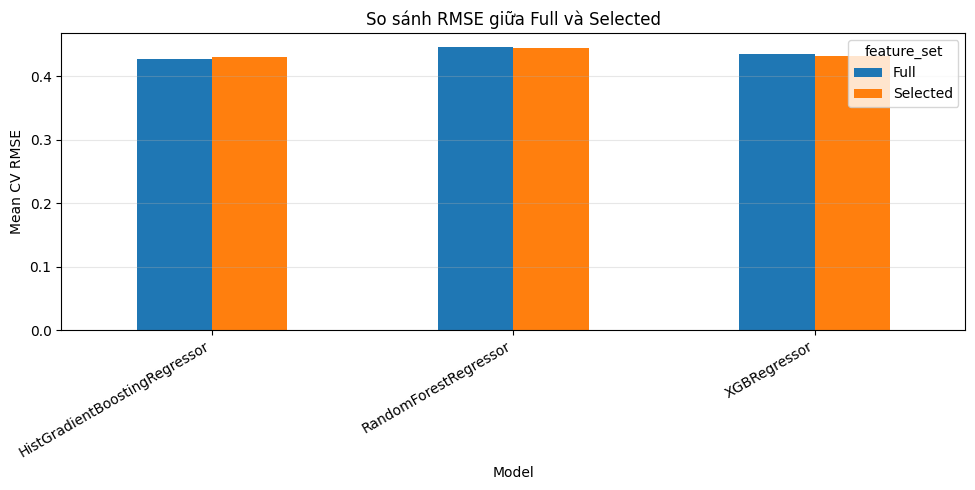

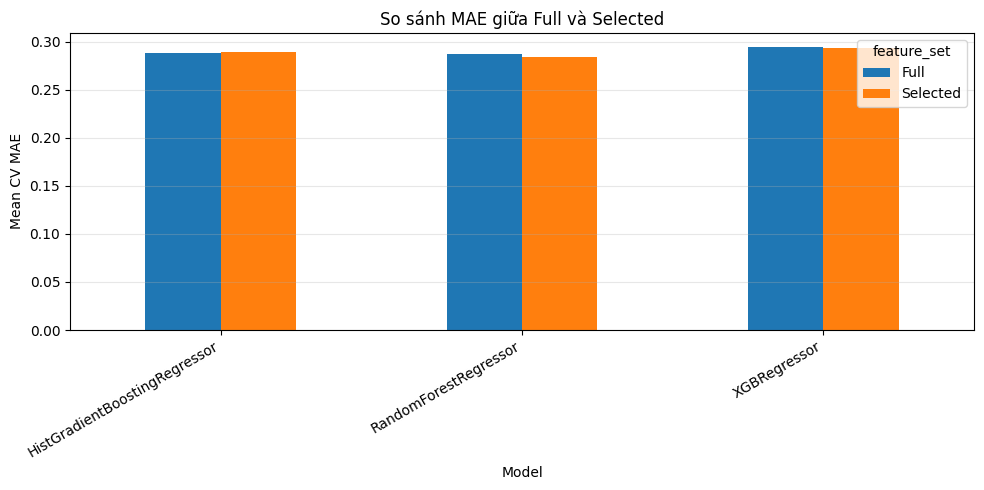

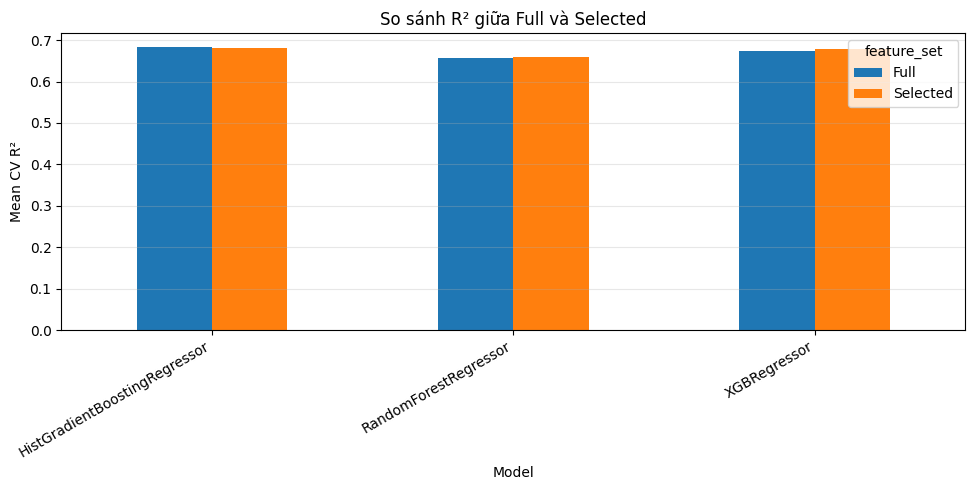

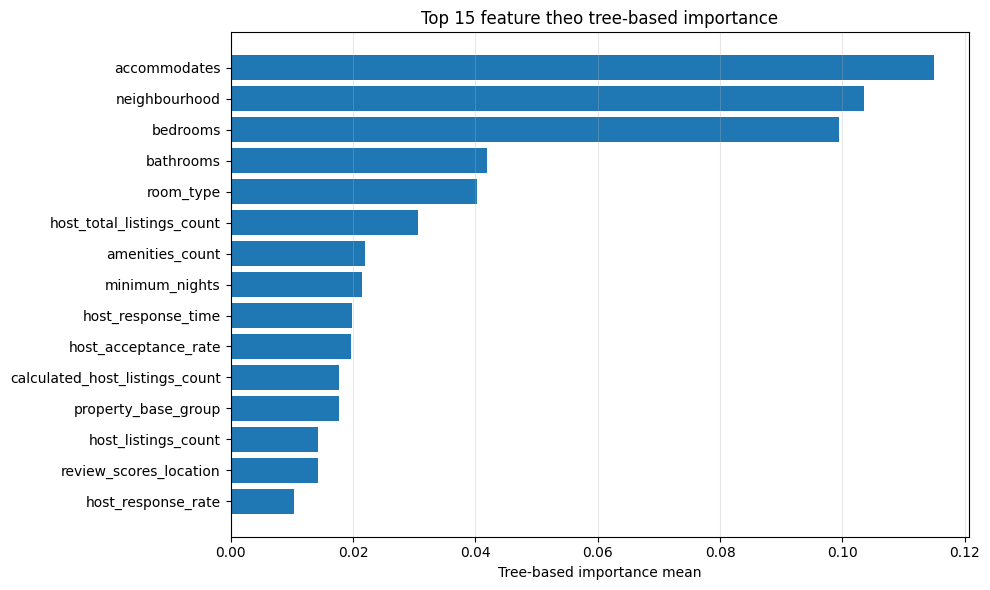

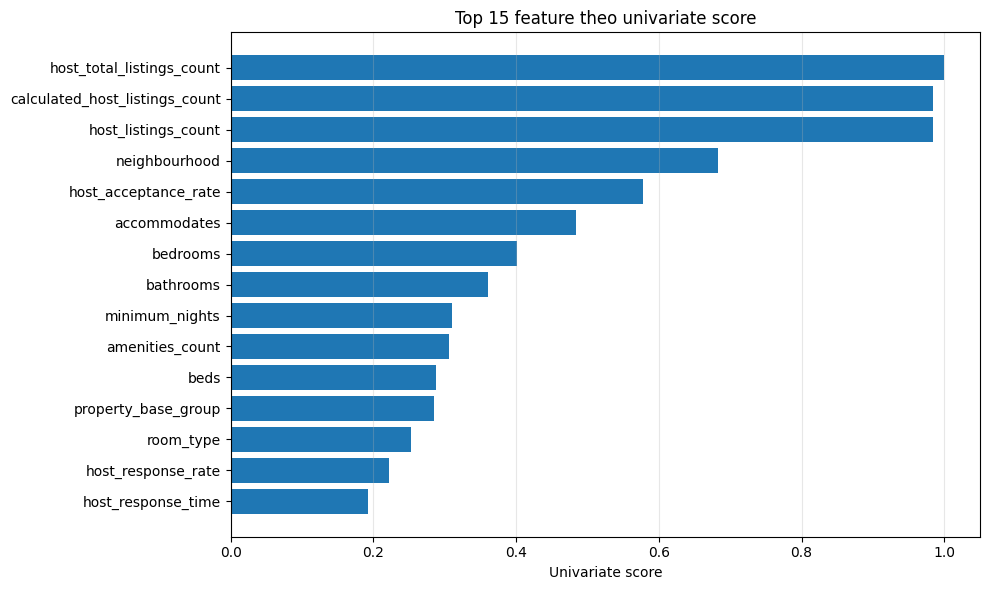

In [31]:
def plot_full_selected_metric(summary, metric, title, ylabel, filename):
    if summary.empty:
        print("No data available for plotting.")
        return

    plot_data = summary.pivot(index="model", columns="feature_set", values=metric)
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_data.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    save_figure(filename, fig)
    plt.show()
    plt.close(fig)


plot_full_selected_metric(
    feature_selection_model_summary,
    "rmse_mean",
    "RMSE comparison: Full vs Selected",
    "Mean CV RMSE",
    "01_feature_selection_rmse_comparison.png",
)
plot_full_selected_metric(
    feature_selection_model_summary,
    "mae_mean",
    "MAE comparison: Full vs Selected",
    "Mean CV MAE",
    "02_feature_selection_mae_comparison.png",
)
plot_full_selected_metric(
    feature_selection_model_summary,
    "r2_mean",
    "R2 comparison: Full vs Selected",
    "Mean CV R2",
    "03_feature_selection_r2_comparison.png",
)

if not tree_feature_summary.empty:
    top_tree_features = tree_feature_summary.sort_values("tree_importance_mean", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_tree_features["feature"], top_tree_features["tree_importance_mean"])
    ax.invert_yaxis()
    ax.set_xlabel("Tree-based importance mean")
    ax.set_title("Top 15 features by tree-based importance")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    save_figure("04_tree_feature_importance.png", fig)
    plt.show()
    plt.close(fig)

if not univariate_feature_summary.empty:
    top_univariate_features = univariate_feature_summary.sort_values("univariate_score", ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_univariate_features["feature"], top_univariate_features["univariate_score"])
    ax.invert_yaxis()
    ax.set_xlabel("Univariate score")
    ax.set_title("Top 15 features by univariate score")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    save_figure("05_univariate_feature_score.png", fig)
    plt.show()
    plt.close(fig)


## Kết luận lựa chọn feature set

Full luôn được đưa vào danh sách ứng viên cuối cùng. Selected chỉ được đưa vào khi giảm đủ số lượng feature, không làm RMSE xấu đi vượt quá ngưỡng cho phép, không làm độ biến động của RMSE tăng mạnh và không khiến thời gian huấn luyện tăng quá mức.

In [ ]:
MAX_RMSE_DEGRADATION_PCT = 0.01
MIN_FEATURE_REDUCTION_PCT = 0.10
MAX_RMSE_STD_INCREASE = 0.005
MAX_FIT_TIME_INCREASE_PCT = 0.20
MAX_FIT_TIME_INCREASE_SECONDS = 1.0

feature_selection_thresholds = {
    "max_rmse_degradation_pct": MAX_RMSE_DEGRADATION_PCT,
    "min_feature_reduction_pct": MIN_FEATURE_REDUCTION_PCT,
    "max_rmse_std_increase": MAX_RMSE_STD_INCREASE,
    "max_fit_time_increase_pct": MAX_FIT_TIME_INCREASE_PCT,
    "max_fit_time_increase_seconds": MAX_FIT_TIME_INCREASE_SECONDS,
}


def build_eligibility_reason(row):
    rejection_reasons = []
    if row["rmse_change_pct"] > MAX_RMSE_DEGRADATION_PCT:
        rejection_reasons.append("Rejected: RMSE degradation exceeded tolerance")
    if row["feature_reduction_pct"] < MIN_FEATURE_REDUCTION_PCT:
        rejection_reasons.append("Rejected: insufficient feature reduction")
    if row["rmse_std_change"] > MAX_RMSE_STD_INCREASE:
        rejection_reasons.append("Rejected: RMSE variability increased excessively")
    if (
        row["fit_time_change"] > MAX_FIT_TIME_INCREASE_SECONDS
        and row["fit_time_change_pct"] > MAX_FIT_TIME_INCREASE_PCT
    ):
        rejection_reasons.append("Rejected: fit time increased excessively")

    if rejection_reasons:
        return "; ".join(rejection_reasons)
    if row["rmse_change_pct"] < 0:
        return "Eligible: improved RMSE and reduced feature count"
    return "Eligible: RMSE degradation within 1% tolerance"


best_model_metrics = {}
best_model_parameters = {}

if feature_selection_model_summary.empty:
    best_feature_set = None
    best_model_after_feature_selection = None
    selected_feature_eligibility = pd.DataFrame()
    print("No feature selection results available for conclusion.")
else:
    selected_eligibility_rows = []
    for model_name in feature_selection_model_summary["model"].unique():
        model_rows = feature_selection_model_summary.query("model == @model_name")
        full_row = model_rows.query("feature_set == 'Full'")
        selected_row = model_rows.query("feature_set == 'Selected'")
        if full_row.empty or selected_row.empty:
            continue

        full_row = full_row.iloc[0]
        selected_row = selected_row.iloc[0]
        full_feature_count = full_row["n_selected_features"]
        selected_feature_count = selected_row["n_selected_features"]
        rmse_change_pct = (selected_row["rmse_mean"] - full_row["rmse_mean"]) / full_row["rmse_mean"]
        mae_change_pct = (selected_row["mae_mean"] - full_row["mae_mean"]) / full_row["mae_mean"]
        r2_change = selected_row["r2_mean"] - full_row["r2_mean"]
        rmse_std_change = selected_row["rmse_std"] - full_row["rmse_std"]
        feature_reduction_pct = (full_feature_count - selected_feature_count) / full_feature_count
        fit_time_change = selected_row["fit_time_mean"] - full_row["fit_time_mean"]
        fit_time_change_pct = fit_time_change / full_row["fit_time_mean"]
        selected_eligible = (
            rmse_change_pct <= MAX_RMSE_DEGRADATION_PCT
            and feature_reduction_pct >= MIN_FEATURE_REDUCTION_PCT
            and rmse_std_change <= MAX_RMSE_STD_INCREASE
            and (
                fit_time_change <= MAX_FIT_TIME_INCREASE_SECONDS
                or fit_time_change_pct <= MAX_FIT_TIME_INCREASE_PCT
            )
        )
        selected_eligibility_rows.append({
            "model": model_name,
            "selected_eligible": selected_eligible,
            "full_feature_count": full_feature_count,
            "selected_feature_count": selected_feature_count,
            "feature_reduction_pct": feature_reduction_pct,
            "rmse_change_pct": rmse_change_pct,
            "mae_change_pct": mae_change_pct,
            "r2_change": r2_change,
            "rmse_std_change": rmse_std_change,
            "fit_time_change": fit_time_change,
            "fit_time_change_pct": fit_time_change_pct,
        })

    selected_feature_eligibility = pd.DataFrame(selected_eligibility_rows)
    if not selected_feature_eligibility.empty:
        selected_feature_eligibility["eligibility_reason"] = selected_feature_eligibility.apply(
            build_eligibility_reason,
            axis=1,
        )
        selected_feature_eligibility = selected_feature_eligibility[[
            "model",
            "selected_eligible",
            "eligibility_reason",
            "full_feature_count",
            "selected_feature_count",
            "feature_reduction_pct",
            "rmse_change_pct",
            "mae_change_pct",
            "r2_change",
            "rmse_std_change",
            "fit_time_change",
            "fit_time_change_pct",
        ]]

    candidate_summary = feature_selection_model_summary.merge(
        selected_feature_eligibility[["model", "selected_eligible"]],
        on="model",
        how="left",
    )
    candidate_summary["candidate_allowed"] = (
        (candidate_summary["feature_set"] == "Full")
        | candidate_summary["selected_eligible"].fillna(False)
    )
    best_row = (
        candidate_summary
        .query("candidate_allowed")
        .sort_values(
            ["rmse_mean", "mae_mean", "r2_mean", "rmse_std"],
            ascending=[True, True, False, True],
        )
        .iloc[0]
    )

    best_feature_set = best_row["feature_set"]
    best_model_after_feature_selection = best_row["model"]
    best_model_metrics = best_row.to_dict()
    best_pipeline = make_candidate_pipelines(best_feature_set).get(best_model_after_feature_selection)
    if best_pipeline is not None:
        best_model_parameters = best_pipeline.named_steps["model"].get_params()

    print(f"Selected final feature set: {best_feature_set}")
    print(f"Best model after feature selection: {best_model_after_feature_selection}")
    print(f"CV RMSE: {best_row['rmse_mean']:.6f}")
    print(f"CV MAE: {best_row['mae_mean']:.6f}")
    print(f"CV R2: {best_row['r2_mean']:.6f}")
    print(f"Feature count: {len(all_original_features)} -> {best_row['n_selected_features']}")

save_dataframe(selected_feature_eligibility, "14_selected_feature_eligibility.csv")

save_json(
    {
        "run_started_at": RUN_STARTED_AT,
        "run_completed_at": datetime.now().isoformat(timespec="seconds"),
        "target": TARGET,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "n_splits": N_SPLITS,
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "input_feature_count": len(X.columns),
        "original_model_feature_count": len(all_original_features),
        "selected_feature_count": len(selected_features),
        "best_model_name": best_model_after_feature_selection,
        "best_feature_set": best_feature_set,
        "best_model_metrics": best_model_metrics,
        "best_model_parameters": best_model_parameters,
        "selected_feature_eligibility": selected_feature_eligibility.to_dict(orient="records"),
        "feature_selection_thresholds": feature_selection_thresholds,
        "metrics": ["mae", "rmse", "r2", "adjusted_r2"],
        "xgboost_available": XGBOOST_AVAILABLE,
        "catboost_available": CATBOOST_AVAILABLE,
        "tree_importance_errors": tree_importance_errors,
        "output_directories": {
            key: format_output_path(path)
            for key, path in OUTPUT_DIRS.items()
        },
        "model_artifact_saved": False,
    },
    "02_modeling_run_metadata.json",
)

selected_feature_eligibility


**Nhận xét:**
- Feature selection được đánh giá theo từng mô hình bằng cách so sánh Selected với Full dựa trên RMSE, MAE, R², độ ổn định của RMSE, mức giảm số lượng feature và thời gian huấn luyện. Selected chỉ được xem là ứng viên hợp lệ khi không làm giảm chất lượng mô hình vượt quá ngưỡng cho phép và thực sự giúp giảm số lượng feature; trong khi đó, Full luôn được giữ lại làm baseline an toàn. Mô hình cuối cùng được lựa chọn từ các ứng viên hợp lệ theo thứ tự ưu tiên RMSE, MAE, R² và RMSE std, sau đó chuyển sang bước lưu artifact, tạo dự đoán hoặc diễn giải insight.
Kết quả cho thấy việc giảm từ 29 xuống còn 22 feature, tương ứng giảm khoảng 24,14%, tạo ra tác động khác nhau đối với từng mô hình.

- Với HistGradientBoostingRegressor, tập Full đạt kết quả tốt hơn nhẹ so với Selected. RMSE tăng từ 0,427621 lên 0,429928 và MAE tăng từ 0,288344 lên 0,289643 khi sử dụng tập feature đã chọn. Mặc dù thời gian huấn luyện giảm nhẹ từ 3,746 giây xuống 3,543 giây, mức cải thiện về tốc độ không đủ lớn để bù lại sự suy giảm về độ chính xác. Vì vậy, tập Full phù hợp hơn với mô hình này.

- Đối với RandomForestRegressor, tập Selected giúp cải thiện nhẹ các chỉ số dự báo. MAE giảm từ 0,287313 xuống 0,283792, RMSE giảm từ 0,445948 xuống 0,443680 và R² tăng từ 0,655829 lên 0,659333. Tuy nhiên, thời gian huấn luyện tăng mạnh từ 45,988 giây lên 457,135 giây. Mức tăng bất thường này khiến tập Selected không được xem là ứng viên hợp lệ cho Random Forest, dù kết quả dự báo có cải thiện.

- Với XGBRegressor, tập Selected mang lại kết quả tốt hơn trên cả độ chính xác và tốc độ. RMSE giảm từ 0,434179 xuống 0,431631, MAE giảm từ 0,294620 xuống 0,293406 và R² tăng từ 0,673764 lên 0,677649. Đồng thời, thời gian huấn luyện giảm từ 3,408 giây xuống 2,394 giây. Do đó, tập Selected là lựa chọn phù hợp hơn đối với XGBRegressor.

- Xét trên toàn bộ các cấu hình hợp lệ, HistGradientBoostingRegressor sử dụng tập Full đạt RMSE thấp nhất là 0,427621 và R² cao nhất là 0,683504. Vì vậy, đây là cấu hình được lựa chọn làm mô hình tốt nhất sau bước feature selection. Kết quả này cho thấy feature selection không cải thiện đồng nhất trên tất cả mô hình và cần được đánh giá riêng cho từng thuật toán thay vì áp dụng một tập feature chung.